# PA 1 – Part B: The Word Embeddings Quest

Welcome, intrepid adventurer, to your hands-on mission into the realm of **word embeddings**, also known as **word vectors**, **semantic vectors**, or **dense representations**. In this quest, you will train your own embeddings using the powerful **SGNS** algorithm (**Skip-gram with Negative Sampling**) and uncover the hidden structure of language lurking within the text.


## The Magic of Word Embeddings

Think of each word as a tiny creature in a vast linguistic universe. **Word embeddings** capture the essence of these creatures by mapping them into a dense vector space. Unlike simple codes or one-hot labels, a word’s meaning is **distributed across all dimensions** of its vector. Each dimension contributes a small clue, and only by looking at the full pattern can we understand the word’s true nature.  

Because these dimensions are shared among words, creatures with similar traits cluster together. This shared, spread-out encoding is called a **distributed representation**, and it allows models to perceive semantic similarity and uncover hidden relationships between words.


## Why This Mission Matters

By mastering distributed word representations, you gain the power to:  
- Compress large vocabularies into compact, expressive vectors  
- Reveal subtle relationships between words that go beyond exact matches  
- Lay the foundation for modern NLP systems that understand meaning, context, and nuance  


## Your Mission Objectives

1. **Master the Learning of Distributed Representations:** Use **Word2Vec (Skip-gram with Negative Sampling)** to extract hidden meaning from text.  
2. **Forge Your Own Word Embeddings:** Train vectors that capture semantic and syntactic relationships between words.  
3. **Test Your Linguistic Insight:** Evaluate the embeddings through **analogy tasks** and **bias measurement**, discovering both the powers and limitations of your learned vectors.  




## Recommended Reading

1. Chapter 5 of [the SLP3 textbook](https://web.stanford.edu/~jurafsky/slp3)  
2. This [illustrated writeup by Jay Alammar](https://jalammar.github.io/illustrated-word2vec/)


## Instructions
- <font color="red">Proceed cell by cell and complete all sections where you are asked to write code.</font>
- <font color="red">Carefully read the course outline for the plagiarism policy and late-day rules.</font>
- <font color="red">Run all cells before submitting to receive full credit.</font>
- <font color="red">Do not delete or modify any pre-written code.</font>
- <font color="red">Attempt every part; each section builds toward a complete understanding.</font>
Failure to follow these rules may result in marks deduction.

## Submission Instructions
- <font color="red">Rename the notebook according to you Student ID. For example if you student ID is 27010001, rename the file to 27010001_PART_A</font>
- <font color="red">Once you're done with both Part A and Part B, zip the folder containing both notebooks and rename the folder to your Student ID as well.</font>


## Part 1 – The Word2Vec Expedition [30 points]

Your first hands-on mission begins here: implementing the legendary **`word2vec`** algorithm.  

`word2vec` is a **powerful framework** for uncovering hidden relationships between words, but in this quest, your focus will be the **Skip-gram model**, just as described in the iconic 2013 paper. To guide you through this adventure, your **primary map** is the lecture slides, with additional insights available in the recommended resources.  

For this expedition, your terrain will be one of the **most epic tales ever told**: <font color="red">~~Harry Potter and the Sorcerer’s Stone~~ </font><font color="teal">**_The Lord of the Rings_** </font>, starting with the first book, <font color="teal">**_The Fellowship of the Ring_**. </font>  

While the full text is a vast and magical landscape, training embeddings on it in its entirety could take far too long. Fear not! We will journey through a **carefully chosen excerpt**

Prepare your tools, adventurer, the path to mastering word embeddings begins now!


In [1]:
# Import in the libraries
# Note: you are NOT allowed to use any other libraries or functions outside of these
# Use the following seeds for reproducibility

import os
import re
import random
from typing import List, Union, Tuple
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from collections import Counter

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

np.random.seed(42)
random.seed(42)

In the cell below, you will:
- Read the entire text file into **one long string** and store it in the variable `data`.  
- Print the **first 300 characters** of `data` to preview the content.  
- Print the **total number of characters** in `data` to check the file size.


In [2]:
#Read in the data
filename = "The Fellowship of the ring.txt"
with open(filename, 'r', encoding='utf-8') as file:
    data = file.read()
print(data[:300])
print(f"Total number of characters: {len(data)}")

J. R. R. Tolkien  The Lord Of The Rings. (1/4)
-----------------------------------------------


     THE LORD OF THE RINGS

              by

     J. R. R. TOLKIEN



 Part 1: The Fellowship of the Ring
 Part 2: The Two Towers
 Part 3: The Return of the King


_Complete with Index and Full Appendi
Total number of characters: 1024531


Write the `Dataset` class from scratch. It must handle the cleaning, tokenization, and indexing of our text.

**Class Requirements:**

1.  **`__init__(self, data)`**:
    * **Clean the Runes:** First, substitute the punctuation characters `,` `!` `?` `;` `-` with a single period `.` to preserve sentence boundaries. (Hint: `re.sub` is your friend).
    * **Tokenize:** Split the text into individual tokens using `word_tokenize`.
    * **Purify:** Keep only tokens that are **alphabetic** OR are exactly a period `.`. Discard numbers and other symbols.
    * **Normalize:** Convert all tokens to **lowercase**.
    * **Build the Archives (Attributes):**
        * `tokens`: The list of all processed tokens.
        * `vocab`: A **sorted** list of unique tokens.
        * `vocab_size`: The total number of unique tokens.
        * `stoi`: A dictionary mapping **String to Index**.
        * `itos`: A dictionary mapping **Index to String**.

2.  **`__len__(self)`**:
    * Return the total number of tokens in the dataset.


---
- The two mappings `stoi` and `itos` will be helpful in fetching your Embeddings later on, since your Embeddings will be a matrix of shape `(vocab_size, embedding_dim)` and the ordering will be dependent on your vocabulary's ordering, that's why its important to sort your vocabulary to have consistent ordering.

In [ ]:
# Define the Dataset class
class Dataset:
#==================== CODE STARTS HERE ====================
  def __init__(self, data):
    cleaned_data = re.sub(r'[,!?;-]', '.', data)         #getting rid of punctuations
    raw_tokens = word_tokenize(cleaned_data)
    self.tokens = []
    for token in raw_tokens:
      token_lower = token.lower()                            #converting everything to lower
      if token_lower.isalpha() or token_lower == '.':          #only keeping alphabets or .
        self.tokens.append(token_lower)

    self.vocab = sorted(list(set(self.tokens)))                   #getting rid of duplicates, making a list and sorting them
    self.vocab_size = len(self.vocab)
    self.stoi = {word: idx for idx, word in enumerate(self.vocab)}
    self.itos = {idx: word for word, idx in self.stoi.items()}                      #making stoi and itos
    
  def __len__(self):
    return len(self.tokens)


#==================== CODE ENDS HERE ====================


#DO NOT MODIFY THE FOLLOWING CODE
dataset = Dataset(data)
print(f"Number of tokens in dataset: {len(dataset)}")
print(f"Vocabulary size: {dataset.vocab_size}")



Number of tokens in dataset: 210096
Vocabulary size: 8451


### The Sliding Window Strategy

To understand the true nature of a word, we cannot look at it in isolation. We must observe the company it keeps.



In the **Skip-gram** model, we slide a "window" over the text. The word in the middle is our **Center Word** (Target), and the words surrounding it are the **Context Words** (Outside).

<center>
<img src="https://jalammar.github.io/images/word2vec/skipgram-sliding-window-2.png">
</center>

**Your Mission:**
Implement the `get_windows` function to generate these training pairs.

**Function Requirements:**

1.  **`get_windows(data, ctx_size)`**:
    * **Inputs:**
        * `data`: A list of tokens (strings or integers).
        * `ctx_size`: An integer representing the radius of the window (how many words to the left and right).

    * **Returns:**
        * Two lists: `outside_words` (a list of lists, where each inner list contains the context tokens) and `center_words` (a list of the target tokens).

**Crucial:** Be careful with your loop range! You cannot start at index 0 or end at the very last index, as you need space for the context on both sides.



In [ ]:
def get_windows(
        data: List[Union[str, int]],
        ctx_size: int
    ):
    """
    Generates sliding windows for dataset creation.

    This function iterates over the input data using a sliding window of total size
    `2 * ctx_size + 1`. For each valid position, it extracts the center word (target)
    and its surrounding neighbors (context).

    Args:
        data (List[Union[str, int]]): The input sequence of tokens (strings or indices).
        ctx_size (int): The context radius (number of words to the left and right of the center).

    Returns:
        Tuple[List, List]:
            - outside_words: A list of context lists (the surrounding words).
            - center_words: A list of target words (the center words).
    """

  #==================== CODE STARTS HERE ====================
    outside_words = []
    center_words = []
    for i in range(ctx_size, len(data) - ctx_size):
        center = data[i]
        context = data[i - ctx_size:i] + data[i + 1:i + ctx_size + 1]           
        center_words.append(center)
        outside_words.append(context)
    return outside_words, center_words


  #==================== CODE ENDS HERE ====================

**Verification:**
After implementing the function, test it using the provided "under the water" sentence below to ensure your window slides correctly.

In [5]:


test_sentence = "The quick brown fox jumps over the lazy dog."
ctx_size = 2
owords, cwords = get_windows(word_tokenize(test_sentence), ctx_size)

# Print as a nice table
print("╔═══════════════════════════╦══════════════╗")
print("║ Context Window            ║ Center Word  ║")
print("╠═══════════════════════════╬══════════════╣")

for context, center in zip(owords, cwords):
    context_str = ", ".join(context)
    print(f"║ {context_str:<25} ║ {center:<12} ║")

print("╚═══════════════════════════╩══════════════╝\n")
expected_context = ['quick', 'brown', 'jumps', 'over']
expected_center = 'fox'
expected_num_windows = 6

assert owords[1] == expected_context and cwords[1] == expected_center and len(owords) == expected_num_windows, \
    f"Test failed! Expected {expected_context} -> {expected_center}, got {owords[1]} -> {cwords[1]}"

print("✅ All tests passed successfully!")


╔═══════════════════════════╦══════════════╗
║ Context Window            ║ Center Word  ║
╠═══════════════════════════╬══════════════╣
║ The, quick, fox, jumps    ║ brown        ║
║ quick, brown, jumps, over ║ fox          ║
║ brown, fox, over, the     ║ jumps        ║
║ fox, jumps, the, lazy     ║ over         ║
║ jumps, over, lazy, dog    ║ the          ║
║ over, the, dog, .         ║ lazy         ║
╚═══════════════════════════╩══════════════╝

✅ All tests passed successfully!


# Training Your Word2Vec Model

Since you’ve built your sliding windows, it’s time to bring your Word2Vec embeddings to life. In this stage, you will traverse the lands of optimization, encounter the trials of negative sampling, and track the treasures of validation loss. Ready your wits and your code.

---



## 1. The Word2Vec Model Structure

Here’s the map for your journey: the structure of your model.

### Initialization

- Randomly initialize two matrices: `W` and `C` of shape `(vocab_size, embedding_dim)`.  
  - `W` holds the **center/target word embeddings**.  
  - `C` holds the **context word embeddings**.  
- Store `stoi` (word → index mapping) and `vocab_size`.  

**Suggested parameters for `__init__`:**  
`vocab_size: int`, `stoi: dict`, `emb_dim: int`

### Loss Computation

For each `(context, target)` pair:

1. Encode the **context** and **target** words as vectors.  
2. Sample **K negative words**.  
3. Compute **dot products** between target and context/negative vectors.  
4. Apply the **sigmoid function** to convert these scores to probabilities.  
5. Compute the **negative sampling loss**, which encourages high probability for true context words and low probability for negative samples.

#### The Gradients: Understanding Impact

Every step updates the embeddings based on **how much they contribute to the loss**. For a target word `w` and context word `c_pos` with negative samples `c_neg_i`:

- **Loss function:**  
$$L_{CE} = -\log \sigma(c_{pos} \cdot w) - \sum_{i=1}^{K} \log \sigma(-c_{neg_i} \cdot w)$$

- **Gradient w.r.t target word `w`:**  
$$\frac{\partial L_{CE}}{\partial w} = [\sigma(c_{pos} \cdot w) - 1]c_{pos} + \sum_{i=1}^{K} [\sigma(c_{neg_i} \cdot w)]c_{neg_i}$$

- **Gradient w.r.t positive context `c_pos`:**  
$$\frac{\partial L_{CE}}{\partial c_{pos}} = [\sigma(c_{pos} \cdot w) - 1]w$$

- **Gradient w.r.t negative sample `c_neg_i`:**  
$$\frac{\partial L_{CE}}{\partial c_{neg_i}} = \sigma(c_{neg_i} \cdot w)w$$

> Intuition: the gradient shows the **impact** of each embedding on the loss. Positive context pulls embeddings closer, negative samples push them apart.

**Suggested Parameters for Loss Computation**

- `context_words: List[List[str]]` — List of context word windows for which to compute the loss  
- `target_words: List[str]` — Corresponding target words  
- `K: int` — Number of negative samples per target word

### Training Procedure

- Shuffle the dataset at the start of each epoch.  
- For each `(context, target)` example:  
  - Encode the words and sample negatives.  
  - Compute dot products, loss, and gradients.  
  - Update embeddings using **stochastic gradient descent (SGD)**.  
- Track **train** and **dev** loss at each epoch to monitor progress.  
- Apply **learning rate decay** to gradually slow down updates as training proceeds.

**Suggested parameters for `train`:**  
- `context_words: List[List[str]]` — List of context word windows for training  
- `target_words: List[str]` — Corresponding target words  
- `dev_context: List[List[str]]` — Context windows for the development/validation set  
- `dev_target: List[str]` — Target words for the development/validation set  
- `num_epochs: int` — Number of training epochs  
- `initial_lr: float` — Initial learning rate for SGD  
- `K: int` — Number of negative samples per target  
- `decay_rate: float` — Learning rate decay applied after each epoch

---

### 🛠 Suggested Steps

1. Use `train_dev_split` to separate `context_words` and `target_words` into **training** and **validation sets**.  
2. Instantiate your `word2vec` model with your chosen **embedding dimension**, `vocab_size`, and `token_counts`.  
3. Implement the `fit` method to **update embeddings via negative sampling**, compute **train and dev loss** at each epoch, and optionally **decay the learning rate**.  
4. Plot **train vs. validation loss** across epochs to track your progress.  
5. Experiment with different hyperparameters (**negative samples, window size, portion of text**) and record your observations.

---

Prepare your wits. This is where your embeddings will earn their wings! Explore the effects of your choices, tune your strategies, and reveal the hidden structure of your textual universe.


In [12]:
# You maye change the following hyperparameters to test out different configurations

USE_TOKENS = 3000
CTX_SIZE = 5
EMB_DIM = 100
NUM_EPOCHS = 5
INITIAL_LR = 0.01
K_NEG = 3
DECAY_RATE = 0.1
DEV_FRACTION = 0.10
SEED = 42



tokens_for_training = dataset.tokens[:USE_TOKENS]
context_words_all, target_words_all = get_windows(tokens_for_training, CTX_SIZE)
n_examples_all = len(target_words_all)
print(f"Created {n_examples_all} examples from first {USE_TOKENS} tokens (ctx_size={CTX_SIZE}).\n")

def train_dev_split(context_words: List[List[str]], target_words: List[str], dev_fraction: float, seed: int = 42) -> Tuple:
    n = len(target_words)
    indices = np.arange(n)
    rng = np.random.RandomState(seed)
    rng.shuffle(indices)
    n_dev = max(1, int(n * dev_fraction))
    dev_idx = indices[:n_dev]
    train_idx = indices[n_dev:]
    train_ctx = [context_words[i] for i in train_idx]
    train_tgt = [target_words[i] for i in train_idx]
    dev_ctx = [context_words[i] for i in dev_idx]
    dev_tgt = [target_words[i] for i in dev_idx]
    return (train_ctx, train_tgt, dev_ctx, dev_tgt)

train_ctx, train_tgt, dev_ctx, dev_tgt = train_dev_split(context_words_all, target_words_all, DEV_FRACTION, seed=SEED)
print(f"Train examples: {len(train_tgt)}, Dev examples: {len(dev_tgt)}\n")





Created 2990 examples from first 3000 tokens (ctx_size=5).

Train examples: 2691, Dev examples: 299



In [ ]:
def sigmoid(x: np.ndarray):
    return 1.0 / (1.0 + np.exp(-x))

#You might wanna implement utility functions down below if required

#--

class Word2Vec:
    """
    Word2Vec model with negative sampling.
    """

    def __init__(
        self,
        vocab_size: int,
        stoi: dict,
        emb_dim: int
    ):
        """
        Initialize the Word2Vec model.
        """
        self.W = np.random.randn(vocab_size, emb_dim) * 0.01
        self.C = np.random.randn(vocab_size, emb_dim) * 0.01               #first thing toh initialized W and c randomly
        self.vocab_size = vocab_size
        self.stoi = stoi
        self.emb_dim = emb_dim
        self.itos = {idx: word for word, idx in stoi.items()}


    def encode(self, x: Union[str, List[str]]):
        """
        Convert word(s) to index/indices.
        """
        return [self.stoi[w] for w in x] if isinstance(x, list) else self.stoi[x]

    def __call__(self, idx: int):
        """
        Return final embedding for a word index.
        """
        return (self.W[idx] + self.C[idx]) / 2.0
    
    def get_negative_samples(self, center_idx: int, K: int):
        """
        Sample K negative word indices uniformly from the vocabulary.
        """
        vocab_indices = list(range(self.vocab_size))
        vocab_indices.remove(center_idx)                           #utility to get the negative samples for training
        return np.random.choice(vocab_indices, size=K, replace=False).tolist()

    def compute_loss(
        self,
        context_words: List[List[str]],
        target_words: List[str],
        K: int
    ) -> float:
        """
        Compute average loss without updating parameters.
        """
        total_loss = 0
        n_examples = len(target_words)
        
        for i in range(n_examples):
            target_idx = self.stoi[target_words[i]]                #for each centre word in the examples i will get its vector from w
            w = self.W[target_idx]
            
            for context_word in context_words[i]:
                context_idx = self.stoi[context_word]              #for the context words of each of those centre words we get their vectors
                c_pos = self.C[context_idx]
                
                pos_score = np.dot(w, c_pos)                       #take dot product of the centre words with context words
                pos_prob = sigmoid(pos_score)             
                total_loss -= np.log(pos_prob)                     #apply sigmoid to get probability and sum the losses, this one is for positive examples btw
                
                neg_samples = self.get_negative_samples(target_idx, K)
                for neg_idx in neg_samples:
                    c_neg = self.C[neg_idx]
                    neg_score = np.dot(w, c_neg)                        #we get to negative samples and do the same thing as we did with pisitive samples
                    neg_prob = sigmoid(neg_score)
                    total_loss -= np.log(1 - neg_prob)
        
        return total_loss / n_examples

    def fit(
        self,
        context_words: List[List[str]],
        target_words: List[str],
        dev_context: List[List[str]],
        dev_target: List[str],
        num_epochs: int,
        initial_lr: float,
        K: int,
        decay_rate: float = 0.0
    ):
        """
        Train the model and track train/dev loss per epoch.
        """
        train_losses = []
        dev_losses = []

        #your code here
        n_examples = len(target_words)
        
        for epoch in range(num_epochs):
            lr = initial_lr / (1 + decay_rate * epoch) 
            epoch_loss = 0 

            indices = np.arange(n_examples)
            np.random.shuffle(indices)                   #shuffle befor every epoch
            
            for idx in indices:
                target_idx = self.stoi[target_words[idx]]
                w = self.W[target_idx]
                for context_word in context_words[idx]:
                    context_idx = self.stoi[context_word]
                    c_pos = self.C[context_idx]
                    
                    pos_score = np.dot(w, c_pos)
                    pos_prob = sigmoid(pos_score)
                    

                    epoch_loss -= np.log(pos_prob)
                    grad_pos_c = (pos_prob - 1) * w
                    grad_w_pos = (pos_prob - 1) * c_pos
                    
                    neg_samples = self.get_negative_samples(target_idx, K)
                    grad_w_neg = np.zeros_like(w)
                    
                    for neg_idx in neg_samples:
                        c_neg = self.C[neg_idx]
                        
                        neg_score = np.dot(w, c_neg)
                        neg_prob = sigmoid(neg_score)
                        epoch_loss -= np.log(1 - neg_prob + 1e-8)
                        grad_neg_c = neg_prob * w
                        self.C[neg_idx] -= lr * grad_neg_c
                        grad_w_neg += neg_prob * c_neg
                
                    self.W[target_idx] -= lr * (grad_w_pos + grad_w_neg)
                    self.C[context_idx] -= lr * grad_pos_c
            
            avg_train_loss = epoch_loss / n_examples
            train_losses.append(avg_train_loss)
            
            dev_loss = self.compute_loss(dev_context, dev_target, K)
            dev_losses.append(dev_loss)
            
            print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Dev Loss: {dev_loss:.4f}, LR: {lr:.6f}")


        return train_losses, dev_losses



Epoch 1/5 - Train Loss: 27.7007, Dev Loss: 27.6254, LR: 0.010000
Epoch 2/5 - Train Loss: 27.1466, Dev Loss: 26.7635, LR: 0.009091
Epoch 3/5 - Train Loss: 25.9632, Dev Loss: 25.6689, LR: 0.008333
Epoch 4/5 - Train Loss: 24.5431, Dev Loss: 24.3944, LR: 0.007692
Epoch 5/5 - Train Loss: 22.8232, Dev Loss: 23.0020, LR: 0.007143


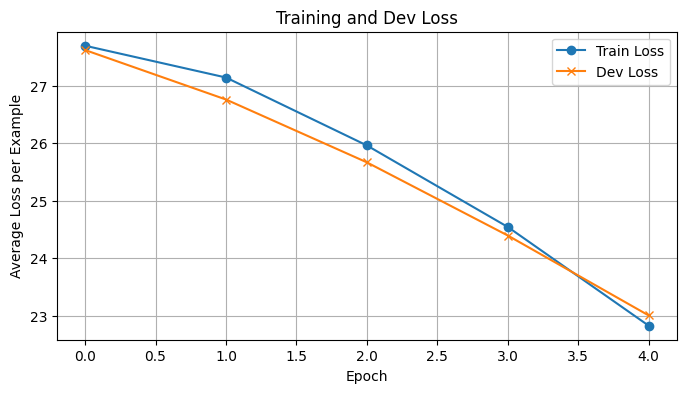

In [14]:
"""
fill in the required parameters for the for the following two calls
"""
# your code here
w2v = Word2Vec(
    vocab_size=dataset.vocab_size,
    stoi=dataset.stoi,
    emb_dim=EMB_DIM
)

train_losses, dev_losses = w2v.fit(
    context_words=train_ctx,
    target_words=train_tgt,
    dev_context=dev_ctx,
    dev_target=dev_tgt,
    num_epochs=NUM_EPOCHS,
    initial_lr=INITIAL_LR,
    K=K_NEG,
    decay_rate=DECAY_RATE
)


#--

# --- Plot losses ---
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(dev_losses, label='Dev Loss', marker='x')
plt.xlabel("Epoch")
plt.ylabel("Average Loss per Example")
plt.title("Training and Dev Loss")
plt.legend()
plt.grid(True)
plt.show()

## 🧪 Reflection: Experimenting with Configurations [10 Points]

Adventurer, you have completed your training journey! Now it’s time to **reflect on your experiments** with Word2Vec.  

**Question:**  

- What different configurations did you try during your experiments? (e.g., negative sampling strategies, window sizes, portions of text, number of negative samples)  
- What impact did each configuration have on the **training and validation loss**?  



**Your Observations:**  

<details>
<summary>
I experimented with with using different number of negative samples for training and saw faster training but lower quality embeddings. I did the same experiment with lesser tokens because training was taking too long and saw the same result, training was faster with lesser tokens but produced lower quality embeddings. I repeated the same experiment with embedding sizes and saw the same result, faster training but poorer embeddings. Thus to produce high quality embeddings i must keep number of tokens max, number of negative samples high and use very large vectors to capture the semantic relations of each word.</summary>







</details>

# Part 2 — Pretrained Embeddings: Tasks & Requirements [10 Points]

<font color="teal"><b>Context.</b></font> Our in-class model was trained on a small excerpt, so its embeddings are limited. You are **free to use any pretrained embeddings** (GloVe, Word2Vec, fastText, etc.) — these larger models will give you richer, more reliable vectors for the exercises below.

For each task below: include the **code cell** that produced the result, print the **top-5** candidates, and attach a short written analysis (2–4 sentences).

---

<font color="teal"><b>Tasks</b></font>

1. <b>Choose & report your pretrained model</b>
   - State which pretrained vectors you used (e.g., <code>glove-wiki-gigaword-200</code>, <code>word2vec-google-news-300</code>, <code>fasttext-wiki-news-subwords-300</code>).  
   - If any target word is out-of-vocabulary (OOV), note it and choose a replacement.

2. <font color="teal"><b>Perfect Analogy (one)</b></font>  
   - Provide one analogy that works *cleanly* with your chosen embeddings.  
   - **Do not** reuse the classic `king - man + woman ≈ queen`. Pick a different analogy (city↔country, verb tense, morphological pair, etc.), run it, print the **top-5** results, and briefly explain why it succeeds.

3. <font color="teal"><b>Imperfect Analogy (one)</b></font>  
   - Find one analogy that **fails or is imperfect** (top answers are incorrect/unrelated).  
   - Print the **top-5** results and explain plausible reasons for the failure (frequency, polysemy, morphological mismatch, corpus bias, etc.).

4. <font color="teal"><b>Bias Detection (one example + short analysis)</b></font>  
   - Design and run one bias check (suggestions: gender↔profession, race↔sentiment, age↔role).  
   - Example pattern:
     ```py
     most_similar(positive=['man','doctor'], negative=['woman'])
     most_similar(positive=['woman','doctor'], negative=['man'])
     ```
   - Print results (top-5 lists) and write a brief analysis describing observed stereotypes and likely corpus causes.

---

<font color="teal"><b>Required deliverables (in your notebook)</b></font>

- A single cell documenting **the pretrained model name** used.  
- One code cell + output for the **perfect analogy** (top-5) and a 2–4 sentence explanation.  
- One code cell + output for the **imperfect analogy** (top-5) and a 2–4 sentence explanation.  
- One code cell + output for the **bias test** (top-5 lists) and a 2–4 sentence analysis.  


---

<font color="teal"><b>Quick tips</b></font>

- Use `gensim` for convenient `most_similar` calls; `gensim.downloader` hosts many pretrained models.  
- For analogy queries, use the pattern `positive=[a,b], negative=[c]` to compute `b - c + a`.  
- Good "perfect analogy" candidates: city→country, verb tense transformations, or clear morphological pairs.  
- Good "imperfect analogy" candidates: rare words, highly polysemous words, or morphological irregularities.  
- Keep written analyses concise and evidence-based.

---

Good luck, explorer! find one shining analogy, one that stumbles, and one that reveals hidden bias.


In [ ]:
#Your code here

import gensim.downloader as api

print("using glove-wiki-gigaword-200")
mymodel = api.load("glove-wiki-gigaword-200")


ModuleNotFoundError: No module named 'gensim'

In [ ]:
result = mymodel.most_similar(positive=['Pakistan', 'India'], negative=['New Delhi'], topn=5)
print("The Analogy (India - New Delhi + Pakistan)=")
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word}: {score}")

This analogy worked perfectly because countries and their capitals appear in very rigid synctactic relations so they have similar embeddings that can be easily learned and then operations like this can be done on them.

In [ ]:
result = mymodel.most_similar(positive=['Ate', 'Drink'], negative=['Eat'], topn=5)
print("The Analogy (Ate - Eat + Drink)=")
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word}: {score}")

In [ ]:
result = mymodel.most_similar(positive=['Man', 'Doctor'], negative=['Woman'], topn=5)
print("The Analogy (Man - Woman + Doctor)=")
for i, (word, score) in enumerate(result, 1):
    print(f"{i}. {word}: {score}")